In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud
from collections import Counter

# Download NLTK resources
nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)

# Load the dataset
df = pd.read_csv('comments.csv')

# Cleanup: Remove unnecessary index columns if present
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0', 'Unnamed: 0.1'])

# Handle missing text data
df = df.dropna(subset=['Text'])

print(f"Data loaded successfully. Total records: {len(df)}")

Data loaded successfully. Total records: 732


PREPROCESSING

In [15]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def preprocess(text):
    # Convert to lowercase and remove non-text elements
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+|https\S+", "", text) # Remove URLs
    text = re.sub(r"@\w+|#\w+", "", text) # Remove mentions/hashtags
    text = text.translate(str.maketrans("", "", string.punctuation)) # Remove punctuation
    text = re.sub(r"\s+", " ", text).strip() # Normalize whitespace

    # Tokenize and Lemmatize
    words = [lemmatizer.lemmatize(word) for word in text.split() if word not in stop_words]
    return " ".join(words)

df["Cleaned_Text"] = df["Text"].apply(preprocess)
print("Preprocessing complete.")

Preprocessing complete.


Sentiment & Platform Analysis

/tmp/ipykernel_1883/1140818238.py:9: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


<Figure size 1000x500 with 0 Axes>

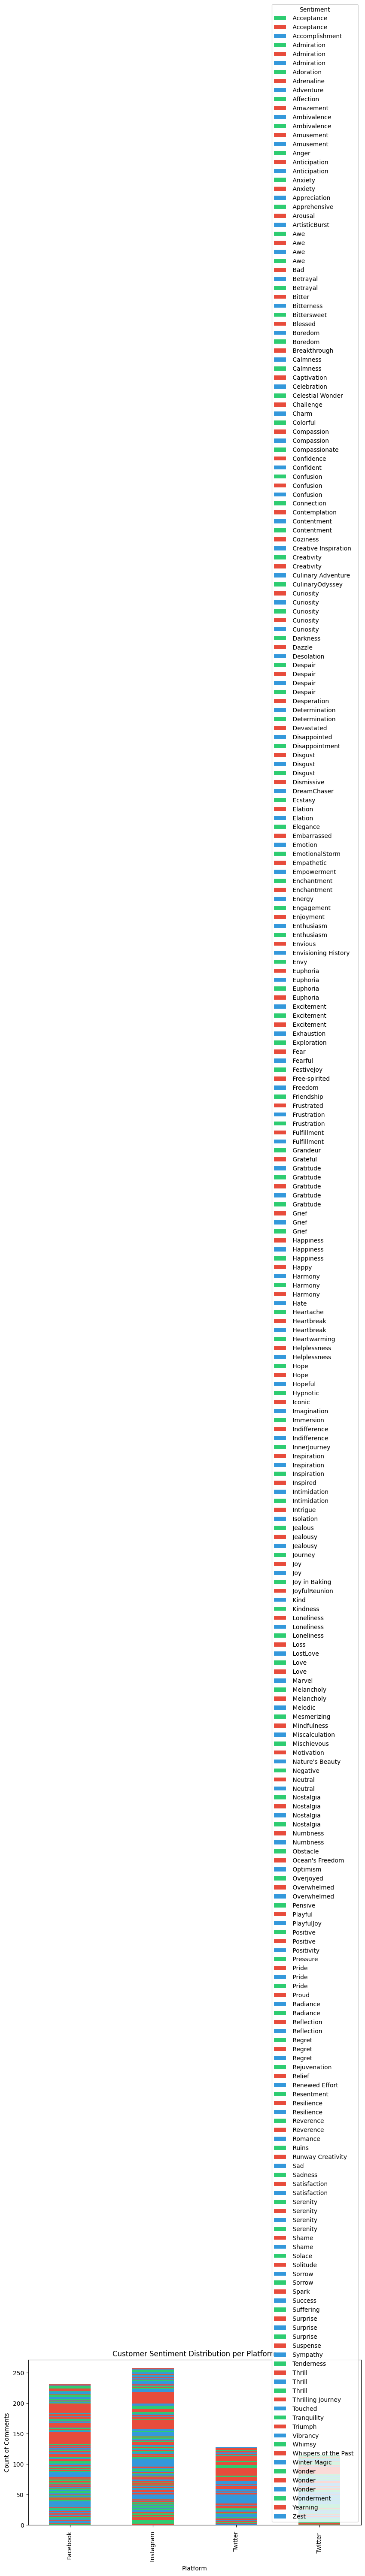

In [16]:
# Create a platform-sentiment cross-tabulation
sentiment_platform = pd.crosstab(df['Platform'], df['Sentiment'])

# Visualization: Sentiment Distribution by Platform
plt.figure(figsize=(10, 5))
sentiment_platform.plot(kind='bar', stacked=True, figsize=(10, 5), color=['#2ecc71', '#e74c3c', '#3498db'])
plt.title("Customer Sentiment Distribution per Platform")
plt.ylabel("Count of Comments")
plt.tight_layout()
plt.show()

Trend Identification

/tmp/ipykernel_1883/2737424534.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Frequency', y='Hashtag', data=tags_df, palette='viridis')


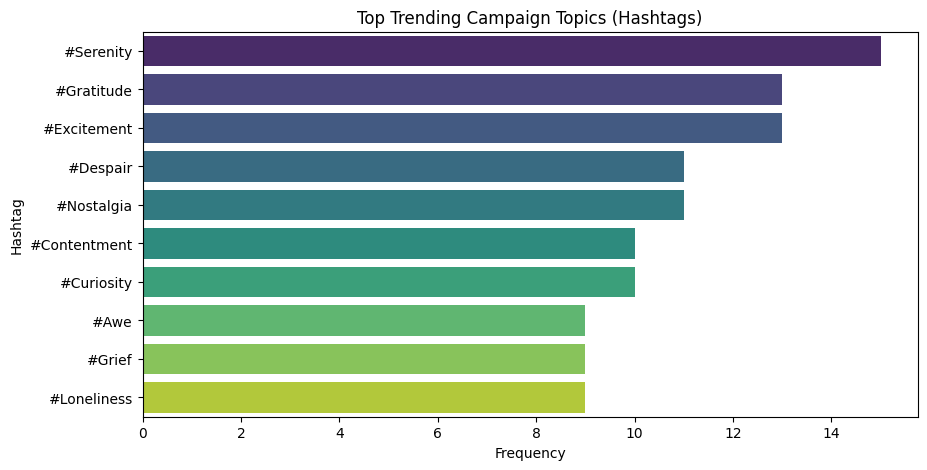

In [17]:
# Flatten hashtags from the 'Hashtags' column
all_hashtags = " ".join(df['Hashtags'].dropna()).split()
hashtag_counts = Counter(all_hashtags).most_common(10)
tags_df = pd.DataFrame(hashtag_counts, columns=['Hashtag', 'Frequency'])

# Visualization: Top Trending Hashtags
plt.figure(figsize=(10, 5))
sns.barplot(x='Frequency', y='Hashtag', data=tags_df, palette='viridis')
plt.title("Top Trending Campaign Topics (Hashtags)")
plt.show()

Public Opinion Visualization

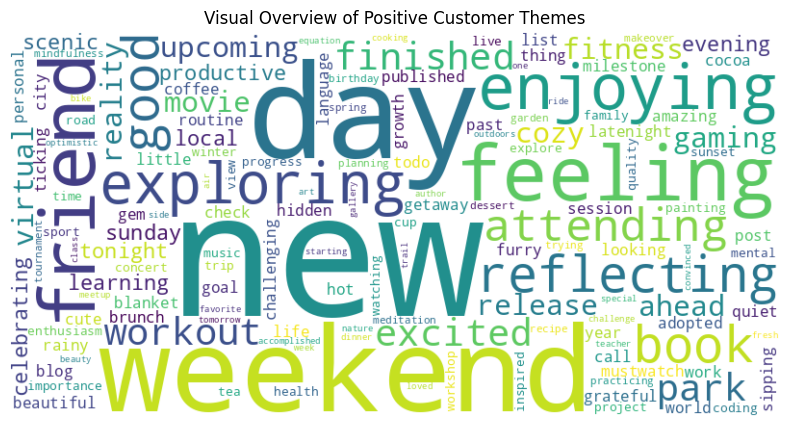

In [18]:
# Generating a word cloud for themes in positive feedback
pos_text = " ".join(df[df['Sentiment'].str.contains('Positive', case=False, na=False)]['Cleaned_Text'])
wordcloud = WordCloud(width=800, height=400, background_color="white").generate(pos_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Visual Overview of Positive Customer Themes")
plt.show()

In [19]:
# Final summary statistics for the report
print("="*60)
print("FINAL BRAND PERCEPTION & SENTIMENT ANALYSIS REPORT")
print("="*60)
print(f"Total Comments Processed: {len(df)}")
print(f"Top Platform by Volume:   {df['Platform'].mode()[0]}")
print(f"Most Frequent Sentiment:  {df['Sentiment'].mode()[0]}")
print("-" * 60)
print("Top Trending Hashtags:")
print(tags_df.head(5).to_string(index=False))
print("="*60)
print("Actionable Business Recommendations:")
print("1. Capitalize on the most active platform (identified above).")
print("2. Engage with users using the top trending hashtags to increase visibility.")
print("3. Analyze negative sentiment clusters to improve specific product areas.")
print("="*60)

FINAL BRAND PERCEPTION & SENTIMENT ANALYSIS REPORT
Total Comments Processed: 732
Top Platform by Volume:    Instagram 
Most Frequent Sentiment:   Positive  
------------------------------------------------------------
Top Trending Hashtags:
    Hashtag  Frequency
  #Serenity         15
 #Gratitude         13
#Excitement         13
   #Despair         11
 #Nostalgia         11
Actionable Business Recommendations:
1. Capitalize on the most active platform (identified above).
2. Engage with users using the top trending hashtags to increase visibility.
3. Analyze negative sentiment clusters to improve specific product areas.
